# Image2GPS Baseline Data and Dataloaders

This notebook loads our train/validation data from the Hugging Face Dataset repo and sets up the baseline-style PyTorch dataset and dataloaders.

If the Hugging Face dataset is private, run `hf auth login` in a terminal first and set `USE_AUTH_TOKEN = True` below. If the dataset is public, the default settings should work without login.

We are not using a local test split for now because the dataset is small and the professor leaderboard/test set is the true held-out test. The notebook follows the example `Release_baseline_model.ipynb` style by creating a custom dataset class and dataloaders before model code.


In [1]:
# Uncomment and run this cell if your kernel is missing dependencies.
%pip install datasets huggingface_hub torch torchvision numpy pillow matplotlib


# Data

## Loading the Train and Validation Datasets

Here we now load our uploaded Hugging Face Dataset directly instead of reading from the local `data/image2gps_dataset/` folder.


In [2]:
HF_DATASET_REPO_ID = "mhedlund/CIS5190IMG2GPS"
print("Dataset repo:", HF_DATASET_REPO_ID)


Dataset repo: mhedlund/CIS5190IMG2GPS


In [3]:
from datasets import load_dataset, Image

dataset_train = load_dataset(HF_DATASET_REPO_ID, split="train")
dataset_validation = load_dataset(HF_DATASET_REPO_ID, split="validation")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/479 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/507M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/392M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1416 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/251 [00:00<?, ? examples/s]

In [4]:
print(dataset_train)
print(dataset_validation)


Dataset({
    features: ['image', 'Latitude', 'Longitude'],
    num_rows: 1416
})
Dataset({
    features: ['image', 'Latitude', 'Longitude'],
    num_rows: 251
})


In [5]:
dataset_train[0]

{'image': <PIL.Image.Image image mode=RGB size=3024x4032>,
 'Latitude': 39.95163055555556,
 'Longitude': -75.19216944444445}

## Defining the Custom Dataset Class

This is the same `GPSImageDataset` pattern from the baseline notebook.

In [6]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np


class GPSImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, lat_mean=None, lat_std=None, lon_mean=None, lon_std=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

        # Compute mean and std from the dataframe if not provided
        self.latitude_mean = lat_mean if lat_mean is not None else np.mean(np.array(self.hf_dataset['Latitude']))
        self.latitude_std = lat_std if lat_std is not None else np.std(np.array(self.hf_dataset['Latitude']))
        self.longitude_mean = lon_mean if lon_mean is not None else np.mean(np.array(self.hf_dataset['Longitude']))
        self.longitude_std = lon_std if lon_std is not None else np.std(np.array(self.hf_dataset['Longitude']))

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # Extract data
        example = self.hf_dataset[idx]

        # Load and process the image
        image = example['image'].convert('RGB')
        latitude = example['Latitude']
        longitude = example['Longitude']
        # image = image.rotate(-90, expand=True)
        if self.transform:
            image = self.transform(image)

        # Normalize GPS coordinates
        latitude = (latitude - self.latitude_mean) / self.latitude_std
        longitude = (longitude - self.longitude_mean) / self.longitude_std
        gps_coords = torch.tensor([latitude, longitude], dtype=torch.float32)

        return image, gps_coords

In [7]:
from torchvision.transforms import InterpolationMode

In [8]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # Random crop and resize to 224x224
    transforms.RandomHorizontalFlip(),  # Random horizontal flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Random color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Optionally, you can create a separate transform for inference without augmentations
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
# Create the training dataset and dataloader
train_dataset = GPSImageDataset(hf_dataset=dataset_train, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Retrieve normalization parameters from the training dataset
lat_mean = train_dataset.latitude_mean
lat_std = train_dataset.latitude_std
lon_mean = train_dataset.longitude_mean
lon_std = train_dataset.longitude_std

print("lat_mean:", lat_mean)
print("lat_std:", lat_std)
print("lon_mean:", lon_mean)
print("lon_std:", lon_std)

lat_mean: 39.95165652367781
lat_std: 0.0006337854727539858
lon_mean: -75.1915309442679
lon_std: 0.0006097230547761085


In [10]:
# Create the validation dataset and dataloader using training mean and std
val_dataset = GPSImageDataset(
    hf_dataset=dataset_validation,
    transform=inference_transform,
    lat_mean=lat_mean,
    lat_std=lat_std,
    lon_mean=lon_mean,
    lon_std=lon_std
)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


## Batch Shape Check

Confirms the image tensors and normalized GPS labels are the expected format.

In [11]:
images, gps_coords = next(iter(train_dataloader))

print("image batch shape:", images.shape)
print("gps batch shape:", gps_coords.shape)
print("first normalized gps label:", gps_coords[0])

image batch shape: torch.Size([32, 3, 224, 224])
gps batch shape: torch.Size([32, 2])
first normalized gps label: tensor([0.3228, 2.0052])


In [12]:
# Convert normalized labels back to raw latitude/longitude for inspection.
gps_coords_denorm = gps_coords * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])
gps_coords_denorm[:5]

tensor([[ 39.9519, -75.1903],
        [ 39.9522, -75.1914],
        [ 39.9516, -75.1918],
        [ 39.9526, -75.1908],
        [ 39.9521, -75.1922]], dtype=torch.float64)

## Visualize Data

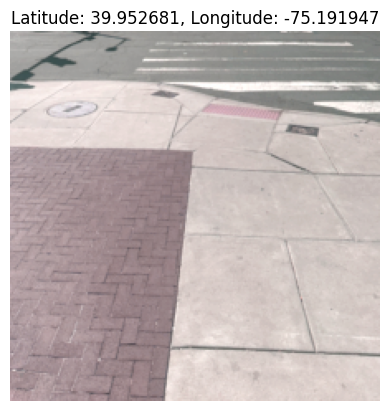

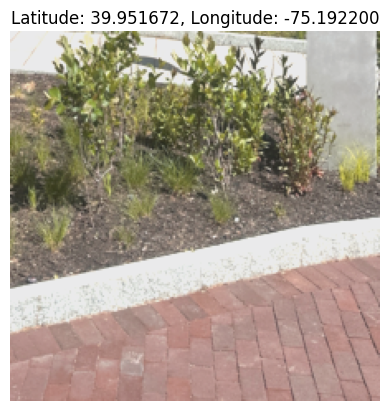

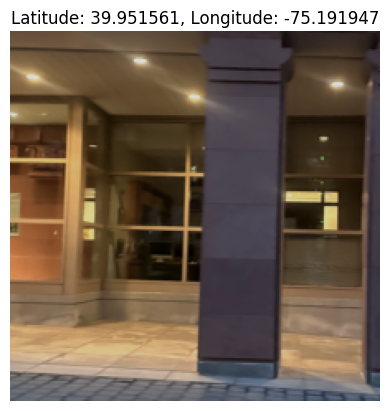

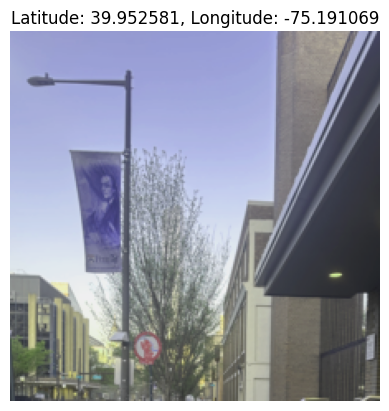

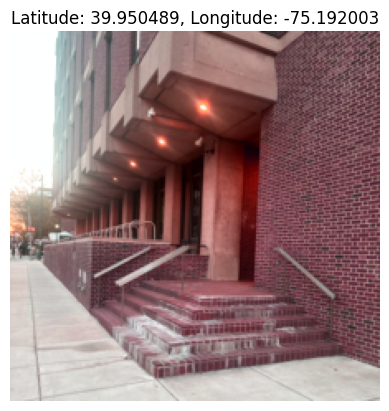

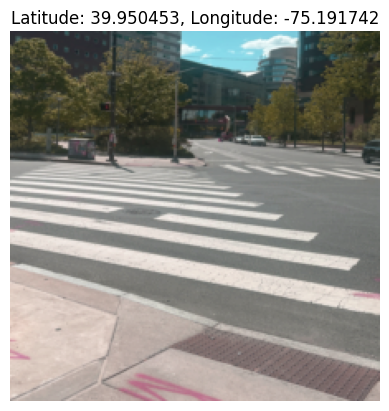

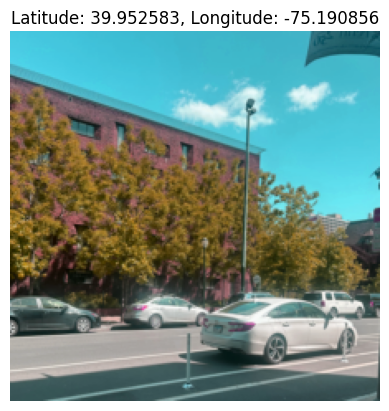

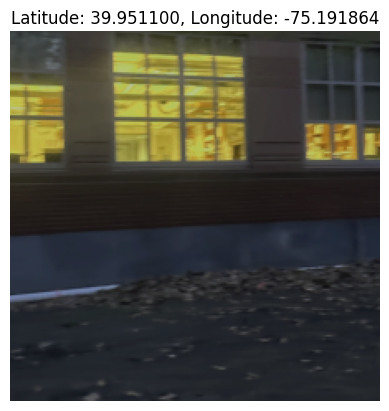

In [13]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np


def denormalize(tensor, mean, std):
    mean = np.array(mean)
    std = np.array(std)
    tensor = tensor.numpy().transpose((1, 2, 0))  # Convert from C x H x W to H x W x C
    tensor = std * tensor + mean
    tensor = np.clip(tensor, 0, 1)
    return tensor


data_iter = iter(train_dataloader)
images, gps_coords = next(data_iter)
gps_coords_real = gps_coords * torch.tensor([lat_std, lon_std]) + torch.tensor([lat_mean, lon_mean])

num_examples = min(8, len(images))
for i in range(num_examples):
    image = denormalize(images[i], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    plt.imshow(image)
    plt.title(
        f"Latitude: {gps_coords_real[i, 0].item():.6f}, "
        f"Longitude: {gps_coords_real[i, 1].item():.6f}"
    )
    plt.axis("off")
    plt.show()


## Next Step

At this point, `train_dataloader` and `val_dataloader` are ready to use for actual model code. Feel free to adjust the transforms or other parts of the pipeline if you think it will make the models behave better in the end!


## Model Architecture

We use ResNet18 as a regression model with 2 outputs.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [15]:
class ResNet18LocationRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        in_features = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)   # output: normalized [latitude, longitude]
        )

        self.register_buffer("lat_mean", torch.tensor(0.0))
        self.register_buffer("lat_std", torch.tensor(1.0))
        self.register_buffer("lon_mean", torch.tensor(0.0))
        self.register_buffer("lon_std", torch.tensor(1.0))

    def forward(self, x):
        return self.model(x)

In [16]:
# Haversine distance in meters. We use this for validation/reporting rather than as the main training loss.

class HaversineDistance(nn.Module):
    def __init__(self, lat_mean, lat_std, lon_mean, lon_std):
        super().__init__()

        self.lat_mean = lat_mean
        self.lat_std = lat_std
        self.lon_mean = lon_mean
        self.lon_std = lon_std

    def forward(self, preds_norm, targets_norm):
        pred_lat = preds_norm[:, 0] * self.lat_std + self.lat_mean
        pred_lon = preds_norm[:, 1] * self.lon_std + self.lon_mean

        true_lat = targets_norm[:, 0] * self.lat_std + self.lat_mean
        true_lon = targets_norm[:, 1] * self.lon_std + self.lon_mean

        pred_lat = torch.deg2rad(pred_lat)
        pred_lon = torch.deg2rad(pred_lon)
        true_lat = torch.deg2rad(true_lat)
        true_lon = torch.deg2rad(true_lon)

        dlat = pred_lat - true_lat
        dlon = pred_lon - true_lon

        a = (
            torch.sin(dlat / 2) ** 2
            + torch.cos(true_lat) * torch.cos(pred_lat) * torch.sin(dlon / 2) ** 2
        )
        a = torch.clamp(a, 0.0, 1.0)

        earth_radius_m = 6_371_000
        distance = 2 * earth_radius_m * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))

        return distance.mean()


In [17]:
# to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18LocationRegressor().to(device)

# Train on normalized coordinate error for stability, and report/save by Haversine distance in meters.
criterion = nn.SmoothL1Loss(beta=0.5)
distance_metric = HaversineDistance(lat_mean, lat_std, lon_mean, lon_std)

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
grad_clip_norm = 1.0


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


## Training and Validation Loop

In [18]:
num_epochs = 10
best_val_distance = float("inf")

for epoch in range(num_epochs):
    # ------------------
    # Training
    # ------------------
    model.train()
    train_loss = 0.0

    for batch_idx, (images, gps_coords) in enumerate(train_dataloader):
        images = images.to(device)
        gps_coords = gps_coords.to(device)

        optimizer.zero_grad(set_to_none=True)

        preds = model(images)
        loss = criterion(preds, gps_coords)

        if not torch.isfinite(loss):
            print(f"Stopping early: non-finite training loss at epoch {epoch + 1}, batch {batch_idx}.")
            print("Reload model.pt from the previous best checkpoint before evaluating or submitting.")
            raise RuntimeError("Non-finite training loss")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_dataloader.dataset)

    # ------------------
    # Validation
    # ------------------
    model.eval()
    val_loss = 0.0
    val_distance = 0.0

    with torch.no_grad():
        for images, gps_coords in val_dataloader:
            images = images.to(device)
            gps_coords = gps_coords.to(device)

            preds = model(images)
            loss = criterion(preds, gps_coords)
            distance = distance_metric(preds, gps_coords)

            if not torch.isfinite(loss) or not torch.isfinite(distance):
                print("Stopping early: non-finite validation metric.")
                print("Reload model.pt from the previous best checkpoint before evaluating or submitting.")
                raise RuntimeError("Non-finite validation metric")

            val_loss += loss.item() * images.size(0)
            val_distance += distance.item() * images.size(0)

    val_loss /= len(val_dataloader.dataset)
    val_distance /= len(val_dataloader.dataset)
    scheduler.step(val_distance)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training SmoothL1 Loss: {train_loss:.6f}")
    print(f"Validation SmoothL1 Loss: {val_loss:.6f}")
    print(f"Validation Haversine Distance: {val_distance:.2f} meters")
    print(f"Learning rate: {optimizer.param_groups[0]['lr']:.2e}")

    if val_distance < best_val_distance:
        best_val_distance = val_distance
        print(f"--> New best model found. Haversine Distance: {best_val_distance:.2f} meters. Saving to model.pt")

        model.lat_mean.fill_(lat_mean)
        model.lat_std.fill_(lat_std)
        model.lon_mean.fill_(lon_mean)
        model.lon_std.fill_(lon_std)

        torch.save(model.state_dict(), "model.pt")

    print("------------------------------")


Epoch 1/10
Training SmoothL1 Loss: 0.549857
Validation SmoothL1 Loss: 0.541767
Validation Haversine Distance: 74.93 meters
Learning rate: 5.00e-05
--> New best model found. Haversine Distance: 74.93 meters. Saving to model.pt
------------------------------
Epoch 2/10
Training SmoothL1 Loss: 0.464905
Validation SmoothL1 Loss: 0.498745
Validation Haversine Distance: 69.46 meters
Learning rate: 5.00e-05
--> New best model found. Haversine Distance: 69.46 meters. Saving to model.pt
------------------------------
Epoch 3/10
Training SmoothL1 Loss: 0.409236
Validation SmoothL1 Loss: 0.433795
Validation Haversine Distance: 62.83 meters
Learning rate: 5.00e-05
--> New best model found. Haversine Distance: 62.83 meters. Saving to model.pt
------------------------------
Epoch 4/10
Training SmoothL1 Loss: 0.373223
Validation SmoothL1 Loss: 0.395401
Validation Haversine Distance: 58.63 meters
Learning rate: 5.00e-05
--> New best model found. Haversine Distance: 58.63 meters. Saving to model.pt
---

In [28]:
num_epochs = 10
best_val_distance = float("inf")

for epoch in range(num_epochs):
    # ------------------
    # Training
    # ------------------
    model.train()
    train_loss = 0.0

    for batch_idx, (images, gps_coords) in enumerate(train_dataloader):
        images = images.to(device)
        gps_coords = gps_coords.to(device)

        optimizer.zero_grad(set_to_none=True)

        preds = model(images)
        loss = criterion(preds, gps_coords)

        if not torch.isfinite(loss):
            print(f"Stopping early: non-finite training loss at epoch {epoch + 1}, batch {batch_idx}.")
            print("Reload model.pt from the previous best checkpoint before evaluating or submitting.")
            raise RuntimeError("Non-finite training loss")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_dataloader.dataset)

    # ------------------
    # Validation
    # ------------------
    model.eval()
    val_loss = 0.0
    val_distance = 0.0

    with torch.no_grad():
        for images, gps_coords in val_dataloader:
            images = images.to(device)
            gps_coords = gps_coords.to(device)

            preds = model(images)
            loss = criterion(preds, gps_coords)
            distance = distance_metric(preds, gps_coords)

            if not torch.isfinite(loss) or not torch.isfinite(distance):
                print("Stopping early: non-finite validation metric.")
                print("Reload model.pt from the previous best checkpoint before evaluating or submitting.")
                raise RuntimeError("Non-finite validation metric")

            val_loss += loss.item() * images.size(0)
            val_distance += distance.item() * images.size(0)

    val_loss /= len(val_dataloader.dataset)
    val_distance /= len(val_dataloader.dataset)
    scheduler.step(val_distance)

    print(f"Epoch {epoch+1 + 10}/{num_epochs}")
    print(f"Training SmoothL1 Loss: {train_loss:.6f}")
    print(f"Validation SmoothL1 Loss: {val_loss:.6f}")
    print(f"Validation Haversine Distance: {val_distance:.2f} meters")
    print(f"Learning rate: {optimizer.param_groups[0]['lr']:.2e}")

    if val_distance < best_val_distance:
        best_val_distance = val_distance
        print(f"--> New best model found. Haversine Distance: {best_val_distance:.2f} meters. Saving to model.pt")

        model.lat_mean.fill_(lat_mean)
        model.lat_std.fill_(lat_std)
        model.lon_mean.fill_(lon_mean)
        model.lon_std.fill_(lon_std)

        torch.save(model.state_dict(), "model.pt")

    print("------------------------------")


Epoch 11/10
Training SmoothL1 Loss: 0.226156
Validation SmoothL1 Loss: 0.280442
Validation Haversine Distance: 45.95 meters
Learning rate: 5.00e-05
--> New best model found. Haversine Distance: 45.95 meters. Saving to model.pt
------------------------------
Epoch 12/10
Training SmoothL1 Loss: 0.232421
Validation SmoothL1 Loss: 0.285428
Validation Haversine Distance: 46.38 meters
Learning rate: 2.50e-05
------------------------------
Epoch 13/10
Training SmoothL1 Loss: 0.231428
Validation SmoothL1 Loss: 0.277115
Validation Haversine Distance: 45.54 meters
Learning rate: 2.50e-05
--> New best model found. Haversine Distance: 45.54 meters. Saving to model.pt
------------------------------
Epoch 14/10
Training SmoothL1 Loss: 0.228061
Validation SmoothL1 Loss: 0.281269
Validation Haversine Distance: 45.86 meters
Learning rate: 1.25e-05
------------------------------
Epoch 15/10
Training SmoothL1 Loss: 0.227096
Validation SmoothL1 Loss: 0.281534
Validation Haversine Distance: 46.07 meters
Le

## View Outputs

Success: model has been reset to the best saved weights.


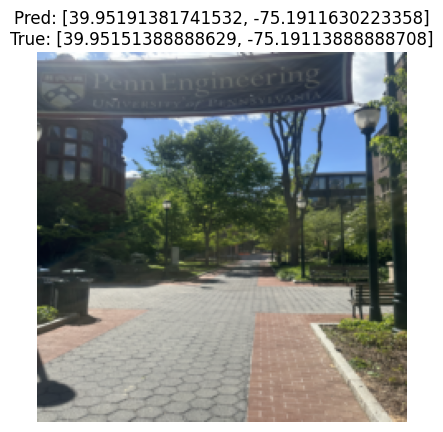

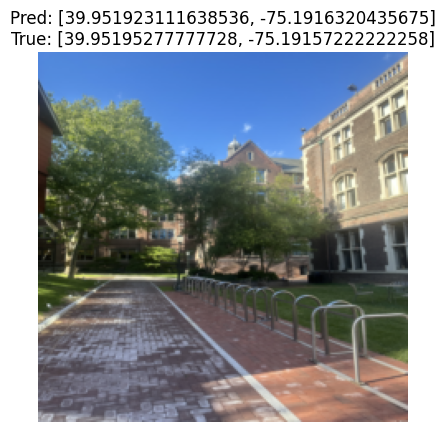

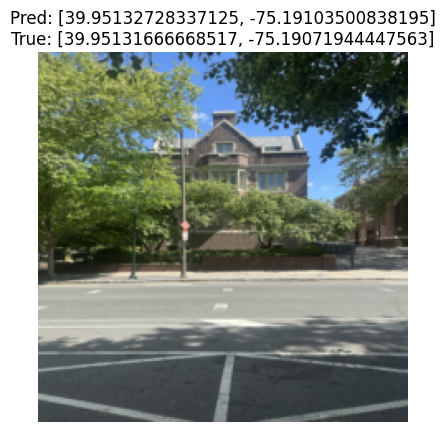

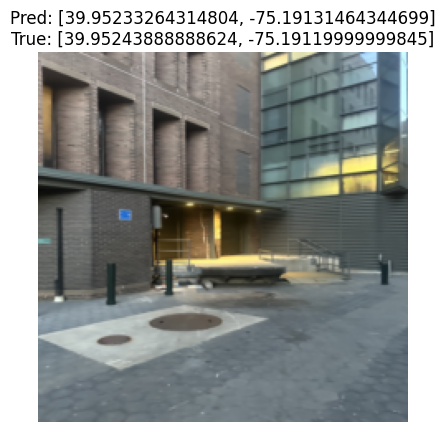

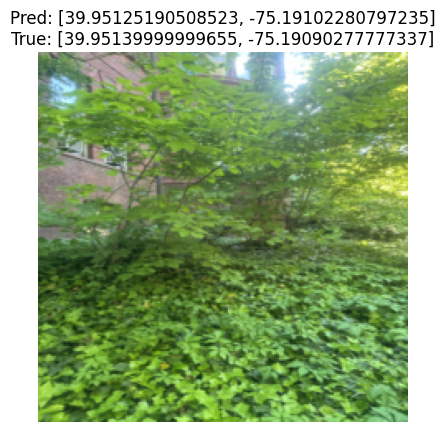

In [19]:
model = ResNet18LocationRegressor().to(device)

# 2. Load the healthy weights from the disk
# map_location='cpu' is a safety measure; .to(device) moves it to GPU afterward
state_dict = torch.load('model.pt', map_location='cpu')
model.load_state_dict(state_dict)
model.to(device)

print("Success: model has been reset to the best saved weights.")

model.eval()

num_examples = 5

images, gps_coords = next(iter(val_dataloader))

images = images[:num_examples].to(device)
gps_coords = gps_coords[:num_examples]

with torch.no_grad():
    preds_norm = model(images).cpu()

stats_mean = torch.tensor([lat_mean, lon_mean])
stats_std = torch.tensor([lat_std, lon_std])

preds_real = preds_norm * stats_std + stats_mean
gps_real = gps_coords * stats_std + stats_mean

for i in range(num_examples):
    img = images[i].cpu()
    img = denormalize(img, mean=[0.485, 0.456, 0.406],
                      std=[0.229, 0.224, 0.225])

    plt.imshow(img)
    plt.title(f"Pred: {preds_real[i].tolist()}\nTrue: {gps_real[i].tolist()}")
    plt.axis("off")
    plt.show()

## Save model.pt

In [30]:
from pathlib import Path

model_path = Path("model.pt")
print("model.pt path:", model_path.resolve())
print("model.pt exists:", model_path.exists())


model.pt path: /content/model.pt
model.pt exists: True


In [31]:
# Optional Colab-only copy to Google Drive.
from google.colab import drive
drive.mount('/content/drive')
!cp model.pt /content/drive/MyDrive/model2.pt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import torch
try:
    # Load with map_location="cpu" to ensure it works regardless of GPU availability
    state_dict = torch.load('model.pt', map_location='cpu')
    print("Success: model.pt loaded.")

    # Print the first few keys to make sure they look like layer names
    print("Sample keys:", list(state_dict.keys())[:5])
except Exception as e:
    print(f"Error: Could not load model.pt. Details: {e}")

Success: model.pt loaded.
Sample keys: ['lat_mean', 'lat_std', 'lon_mean', 'lon_std', 'model.conv1.weight']


## Professor-Released Validation Set

The professors provided a 100-image Hugging Face dataset, `gydou/released_img`, that should be closer to the hidden leaderboard test distribution than our internal validation split. Run this section after training so it can evaluate the saved `model.pt` checkpoint on that released validation set.

In [23]:
RELEASED_DATASET_REPO_ID = "gydou/released_img"

released_dataset = load_dataset(RELEASED_DATASET_REPO_ID, split="train")
print(released_dataset)
print("columns:", released_dataset.column_names)
released_dataset[0]

README.md:   0%|          | 0.00/360 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/307M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'Latitude', 'Longitude'],
    num_rows: 100
})
columns: ['image', 'Latitude', 'Longitude']


{'image': <PIL.Image.Image image mode=RGB size=3000x4000>,
 'Latitude': 39.9516483,
 'Longitude': -75.19224499972222}

In [24]:
def standardize_gps_columns(ds):
    lat_aliases = ["Latitude", "latitude", "lat"]
    lon_aliases = ["Longitude", "longitude", "lon", "lng"]

    lat_col = next((col for col in lat_aliases if col in ds.column_names), None)
    lon_col = next((col for col in lon_aliases if col in ds.column_names), None)

    if lat_col is None or lon_col is None:
        raise ValueError(f"Could not find GPS label columns in {ds.column_names}")

    if lat_col != "Latitude":
        ds = ds.rename_column(lat_col, "Latitude")
    if lon_col != "Longitude":
        ds = ds.rename_column(lon_col, "Longitude")
    return ds


released_dataset = standardize_gps_columns(released_dataset)

released_val_dataset = GPSImageDataset(
    hf_dataset=released_dataset,
    transform=inference_transform,
    lat_mean=lat_mean,
    lat_std=lat_std,
    lon_mean=lon_mean,
    lon_std=lon_std,
)
released_val_dataloader = DataLoader(released_val_dataset, batch_size=32, shuffle=False)

print("released validation examples:", len(released_val_dataset))

released validation examples: 100


In [25]:
from pathlib import Path

# Use the best checkpoint saved during training if it exists.
if Path("model.pt").exists():
    state_dict = torch.load("model.pt", map_location="cpu")
    model.load_state_dict(state_dict)
    model.to(device)
    print("Loaded model.pt for professor-released validation evaluation.")
else:
    print("model.pt not found; evaluating the current in-memory model instead.")

model.eval()

Loaded model.pt for professor-released validation evaluation.


ResNet18LocationRegressor(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [26]:
def haversine_distance_m(preds_norm, targets_norm, lat_mean, lat_std, lon_mean, lon_std):
    pred_lat = preds_norm[:, 0] * lat_std + lat_mean
    pred_lon = preds_norm[:, 1] * lon_std + lon_mean
    true_lat = targets_norm[:, 0] * lat_std + lat_mean
    true_lon = targets_norm[:, 1] * lon_std + lon_mean

    pred_lat = torch.deg2rad(pred_lat)
    pred_lon = torch.deg2rad(pred_lon)
    true_lat = torch.deg2rad(true_lat)
    true_lon = torch.deg2rad(true_lon)

    dlat = pred_lat - true_lat
    dlon = pred_lon - true_lon
    a = (
        torch.sin(dlat / 2) ** 2
        + torch.cos(true_lat) * torch.cos(pred_lat) * torch.sin(dlon / 2) ** 2
    )
    a = torch.clamp(a, 0.0, 1.0)
    return 2 * 6_371_000 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))


def evaluate_gps_model(model, dataloader):
    all_preds_norm = []
    all_targets_norm = []

    model.eval()
    with torch.no_grad():
        for images, gps_coords in dataloader:
            images = images.to(device)
            preds_norm = model(images).cpu()
            all_preds_norm.append(preds_norm)
            all_targets_norm.append(gps_coords.cpu())

    preds_norm = torch.cat(all_preds_norm)
    targets_norm = torch.cat(all_targets_norm)

    model_errors_m = haversine_distance_m(
        preds_norm, targets_norm, lat_mean, lat_std, lon_mean, lon_std
    )
    train_mean_preds_norm = torch.zeros_like(targets_norm)
    train_mean_errors_m = haversine_distance_m(
        train_mean_preds_norm, targets_norm, lat_mean, lat_std, lon_mean, lon_std
    )

    stats_mean = torch.tensor([lat_mean, lon_mean])
    stats_std = torch.tensor([lat_std, lon_std])
    preds_real = preds_norm * stats_std + stats_mean
    targets_real = targets_norm * stats_std + stats_mean

    return preds_real, targets_real, model_errors_m, train_mean_errors_m


released_preds, released_targets, released_errors_m, released_mean_errors_m = evaluate_gps_model(
    model, released_val_dataloader
)

print(f"Released validation model mean error: {released_errors_m.mean().item():.2f} meters")
print(f"Released validation model median error: {released_errors_m.median().item():.2f} meters")
print(f"Train-mean GPS baseline mean error: {released_mean_errors_m.mean().item():.2f} meters")
print(f"Train-mean GPS baseline median error: {released_mean_errors_m.median().item():.2f} meters")

Released validation model mean error: 53.46 meters
Released validation model median error: 47.38 meters
Train-mean GPS baseline mean error: 84.33 meters
Train-mean GPS baseline median error: 76.73 meters


In [27]:
import pandas as pd

released_results_df = pd.DataFrame(
    {
        "pred_lat": released_preds[:, 0].numpy(),
        "pred_lon": released_preds[:, 1].numpy(),
        "true_lat": released_targets[:, 0].numpy(),
        "true_lon": released_targets[:, 1].numpy(),
        "error_m": released_errors_m.numpy(),
        "train_mean_baseline_error_m": released_mean_errors_m.numpy(),
    }
)

display(released_results_df.describe())
display(released_results_df.sort_values("error_m", ascending=False).head(10))

,pred_lat,pred_lon,true_lat,true_lon,error_m,train_mean_baseline_error_m
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,39.951730,-75.191406,39.951844,-75.191480,53.458134,84.326065
std,0.000501,0.000380,0.000634,0.000641,35.512032,35.182854
min,39.950872,-75.192342,39.950405,-75.192570,5.091450,10.043344
25%,39.951352,-75.191647,39.951410,-75.191943,24.457172,68.815247
50%,39.951669,-75.191453,39.951957,-75.191575,48.081669,76.729652
75%,39.952132,-75.191179,39.952402,-75.191199,78.971319,108.871397
max,39.953062,-75.189926,39.952647,-75.190111,168.663132,153.641312


,pred_lat,pred_lon,true_lat,true_lon,error_m,train_mean_baseline_error_m
76,39.951116,-75.191598,39.952614,-75.191903,168.663132,111.242332
81,39.951363,-75.191502,39.952625,-75.191697,141.515045,108.747917
79,39.951510,-75.191393,39.952622,-75.191789,128.107040,109.720406
10,39.951581,-75.192129,39.950435,-75.192250,127.644241,148.713669
72,39.951687,-75.191135,39.952478,-75.192161,124.460022,106.039902
9,39.951273,-75.191487,39.950405,-75.192292,118.420090,153.275558
34,39.951213,-75.191158,39.952006,-75.190269,115.859367,114.461296
37,39.951832,-75.191096,39.952503,-75.190111,112.109039,153.407898
75,39.951652,-75.191746,39.952603,-75.192017,108.106216,113.018990
11,39.951250,-75.191622,39.950435,-75.192250,105.058762,148.713669
